# Lumbar Spinal MRI Classification — DINO Self-Supervised Pretraining

**Method:** DINO (self-**DI**stillation with **NO** labels; Caron et al., 2021),
applied on top of the three best-performing backbones from the supervised
study — **VGG16**, **ResNet50**, and **ConvNeXt Small**.

This notebook produces the **DINO leg** of the self-/semi-supervised
comparison (BYOL, DINO, STAC, FixMatch × {VGG16, ResNet50, ConvNeXt Small} =
12 models). Same dataset split, preprocessing, and evaluation protocol as the
supervised/BYOL notebooks (same `SEED`, same 70/20/10 stratified split, same
`timm` backbone identifiers) so results are directly comparable.


## How DINO works here, and how it differs from BYOL (read this first)

DINO and BYOL are both self-supervised and use the **exact same** labeled/unlabeled
protocol: pretraining uses **all** of the 70% training split with labels
discarded, then the **same** images (now with labels) are used for
fine-tuning. Validation/test are never touched during pretraining. If you've
already read the BYOL notebook's data-usage section, the partitioning logic
here is identical.

Where DINO differs is the **pretraining algorithm** itself:

| | BYOL | DINO |
|---|---|---|
| Student/teacher | Online network + EMA target network | Student network + EMA teacher network (same idea, different name) |
| Extra module | A **predictor** MLP only on the online side | **No predictor** — instead, the teacher output is **centered** and **sharpened** (low temperature) |
| Views per image | 2 (both roughly the same crop scale) | **Multi-crop**: 2 large "global" crops + several small "local" crops per image |
| Who sees what | Both views go through both networks | The **student** sees all crops (global + local); the **teacher** only ever sees the 2 global crops |
| Loss | Negative cosine similarity between predicted projections | Cross-entropy between the (sharpened, centered) teacher distribution and the student's distribution, summed over every student-crop / teacher-crop pair except identical-view pairs |
| Anti-collapse mechanism | Predictor + stop-gradient + EMA | Centering (running mean of teacher outputs) + sharpening (low teacher temperature) + stop-gradient + EMA |

Both use the same underlying self-supervised "protocol" (pretrain the
backbone with no labels, then fine-tune with labels), so re-reading BYOL's
"how labeled/unlabeled data is used" section applies verbatim here.

### Design choices made for time/compute budget (stated honestly)
- `PRETRAINED_INIT = True` by default, same reasoning as BYOL: with ~9,580
  training images and a hard deadline, DINO continues from ImageNet weights
  (self-supervised *domain-adaptive* pretraining) rather than random init.
  Describe it that way in the paper, same as for BYOL.
- The original DINO paper uses 2 global + **6** local crops and an output
  dimension of 65,536. Here it's 2 global + **4** local crops and an output
  dimension of **8,192** — smaller and faster while keeping the same
  algorithm, appropriate for a 3-class, ~13K-image dataset rather than
  ImageNet-scale pretraining. Both are configurable below.
- The paper's "freeze the last layer's gradient for the first epoch"
  stability trick is intentionally **not** implemented — it is a minor
  stabilization tweak, not part of the core algorithm, and skipping it keeps
  the implementation simpler and easier to verify correct. Instead, the same
  fix already validated for BYOL is used here: a much smaller learning rate
  for the (unnormalized, no-BatchNorm-in-VGG16) backbone than for the
  freshly-initialized head, with warmup + cosine decay and gradient clipping.
  This is what actually prevented the VGG16 NaN issue you hit with BYOL, and
  the same risk exists here for the same reason (VGG16 has no BatchNorm).

### Honest expectation-setting (same as BYOL)
DINO pretraining followed by fine-tuning is not guaranteed to beat the fully
supervised baseline — it may match, trail, or occasionally exceed it. The
code below reports the true number either way; it is not tuned to force a
particular outcome.


## Install Dependencies

In [1]:
!pip install -q timm

## Configuration

In [2]:
from pathlib import Path

SEED = 42
DATASET_ZIP = None
EXPECTED_CLASSES = ['Herniated Disc', 'No Stenosis', 'Thecal Sac']
EXPECTED_TOTAL_IMAGES = 13686

TRAIN_RATIO = 0.70
VAL_RATIO = 0.20
TEST_RATIO = 0.10

INPUT_SIZE = 224
BATCH_SIZE = 32          # supervised fine-tuning stage batch size
HEAD_EPOCHS = 5          # linear-probe (frozen backbone) epochs during fine-tuning
FINE_TUNE_EPOCHS = 25    # full fine-tuning epochs

HEAD_LR = 3e-4
BACKBONE_LR = 1e-5
FINE_TUNE_HEAD_LR = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.40
LABEL_SMOOTHING = 0.05
PATIENCE = 8
MIN_DELTA = 1e-4

REMOVE_EXACT_DUPLICATES = True
RESUME_IF_AVAILABLE = True   # both pretraining and fine-tuning are resumable
EXPERIMENT_ID = 'lumbar_mri_dino_224_v1'

OUTPUT_DIR = Path('/kaggle/working') / EXPERIMENT_ID
EXTRACT_DIR = OUTPUT_DIR / 'extracted_dataset'
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
FIGURE_DIR = OUTPUT_DIR / 'paper_figures'
TABLE_DIR = OUTPUT_DIR / 'tables'

# Same three architectures, same timm identifiers as the supervised/BYOL notebooks
MODEL_SPECS = {
    'VGG16': {'timm_name': 'vgg16.tv_in1k'},
    'ResNet50': {'timm_name': 'resnet50.tv_in1k'},
    'ConvNeXtSmall': {'timm_name': 'convnext_small.fb_in22k_ft_in1k'},
}
MODELS_TO_RUN = list(MODEL_SPECS)

# ---- DINO-specific configuration ----
METHOD_NAME = 'DINO'
PRETRAINED_INIT = True          # see markdown above: True = domain-adaptive DINO from ImageNet weights
DINO_PRETRAIN_EPOCHS = 15       # same budget as the BYOL notebook; raise/lower to fit your time budget
DINO_BATCH_SIZE = 16            # kept modest: each step forwards 2 global (224px) + N local (96px) crops per image

DINO_GLOBAL_CROPS = 2
DINO_LOCAL_CROPS = 2            # paper default is 6; reduced for time/compute budget
DINO_GLOBAL_CROP_SIZE = 224
DINO_LOCAL_CROP_SIZE = 96
DINO_GLOBAL_CROP_SCALE = (0.4, 1.0)
DINO_LOCAL_CROP_SCALE = (0.05, 0.4)

DINO_HIDDEN_DIM = 2048          # DINOHead MLP hidden size (matches paper default)
DINO_BOTTLENECK_DIM = 256       # DINOHead bottleneck size (matches paper default)
DINO_OUT_DIM = 8192             # paper default is 65536; reduced for a small 3-class dataset
AMP_UNSTABLE_MODELS = {'VGG16'}   # no BatchNorm -> prone to fp16 overflow; train these in fp32

DINO_BASE_MOMENTUM = 0.996      # EMA momentum for the teacher network, cosine-annealed to 1.0
DINO_WARMUP_TEACHER_TEMP = 0.04
DINO_TEACHER_TEMP = 0.07
DINO_TEACHER_TEMP_WARMUP_EPOCHS = 5
DINO_STUDENT_TEMP = 0.1
DINO_CENTER_MOMENTUM = 0.9

DINO_BACKBONE_LR = 5e-5         # small LR for the pretrained backbone (prevents the VGG16 fp16-NaN issue)
DINO_HEAD_LR = 1e-3             # larger LR for the freshly-initialized DINOHead
DINO_WEIGHT_DECAY = 1.5e-6
DINO_WARMUP_STEPS_RATIO = 0.05
DINO_GRAD_CLIP_NORM = 1.0


## Imports and Reproducibility

In [3]:
import gc
import hashlib
import itertools
import json
import math
import os
import random
import shutil
import time
import warnings
import zipfile
from concurrent.futures import ThreadPoolExecutor
from contextlib import nullcontext

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageFile
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
ImageFile.LOAD_TRUNCATED_IMAGES = True

for path in [OUTPUT_DIR, EXTRACT_DIR, CHECKPOINT_DIR, FIGURE_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    torch.set_float32_matmul_precision('high')
except Exception:
    pass

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'
NUM_WORKERS = min(4, os.cpu_count() or 2)
PIN_MEMORY = DEVICE.type == 'cuda'

try:
    DINO_WEIGHT_NORM = nn.utils.parametrizations.weight_norm
except AttributeError:
    DINO_WEIGHT_NORM = nn.utils.weight_norm

print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print(f'timm: {timm.__version__}')


Device: cuda
PyTorch: 2.10.0+cu128
timm: 1.0.26


## Dataset Discovery

In [4]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
SEARCH_ROOTS = [Path('/kaggle/input'), Path('/mnt/data')]
DATASET_KEYWORDS = ('lumbar', 'lumber', 'spinal', 'stenosis')


def zip_score(path):
    name = path.name.lower()
    keyword_score = sum(keyword in name for keyword in DATASET_KEYWORDS)
    return keyword_score * 10_000_000 + path.stat().st_size


def discover_zip():
    if DATASET_ZIP is not None:
        path = Path(DATASET_ZIP)
        if not path.exists():
            raise FileNotFoundError(f'DATASET_ZIP does not exist: {path}')
        return path

    candidates = []
    for root in SEARCH_ROOTS:
        if root.exists():
            candidates.extend(root.rglob('*.zip'))

    candidates = [
        path for path in candidates
        if any(keyword in path.name.lower() for keyword in DATASET_KEYWORDS)
    ]
    return max(candidates, key=zip_score) if candidates else None


def class_image_folders(root):
    folders = []
    for current, dirs, _ in os.walk(root):
        current_path = Path(current)
        if current_path.name in EXPECTED_CLASSES:
            has_images = any(
                path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
                for path in current_path.iterdir()
            )
            if has_images:
                folders.append(current_path)
            dirs[:] = []
    return folders


def discover_image_root():
    archive = discover_zip()
    if archive is not None:
        marker = EXTRACT_DIR / '.extracted'
        signature = f'{archive}:{archive.stat().st_size}'
        if not marker.exists() or marker.read_text().strip() != signature:
            if EXTRACT_DIR.exists():
                shutil.rmtree(EXTRACT_DIR)
            EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(archive) as zipped:
                zipped.extractall(EXTRACT_DIR)
            marker.write_text(signature)
        return EXTRACT_DIR, archive

    for root in SEARCH_ROOTS:
        if root.exists() and class_image_folders(root):
            return root, None

    raise FileNotFoundError('The Lumbar Spinal MRI dataset was not found.')


DATA_ROOT, ARCHIVE_PATH = discover_image_root()
CLASS_FOLDERS = class_image_folders(DATA_ROOT)
found_classes = sorted({folder.name for folder in CLASS_FOLDERS})

if found_classes != sorted(EXPECTED_CLASSES):
    raise ValueError(f'Expected {EXPECTED_CLASSES}, but found {found_classes}')

print(f'Archive: {ARCHIVE_PATH}')
print(f'Data root: {DATA_ROOT}')
print(f'Class folders: {len(CLASS_FOLDERS)}')


Archive: None
Data root: /kaggle/input
Class folders: 6


## Dataset Audit and Duplicate Control

In [5]:
def infer_original_split(path):
    lowered = [part.lower() for part in Path(path).parts]
    for split_name in ['train', 'validation', 'valid', 'val', 'test']:
        if split_name in lowered:
            return split_name
    return 'unspecified'


def inspect_image(path):
    try:
        with open(path, 'rb') as file:
            content = file.read()

        digest = hashlib.sha256(content).hexdigest()

        with Image.open(path) as image:
            width, height = image.size
            mode = image.mode
            image.verify()

        return str(path), True, digest, width, height, mode, ''
    except Exception as exc:
        return str(path), False, '', np.nan, np.nan, '', str(exc)


records = []
for folder in sorted(CLASS_FOLDERS, key=lambda path: (path.name, str(path))):
    for path in sorted(folder.iterdir()):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            records.append({
                'path': str(path),
                'class_name': folder.name,
                'original_split': infer_original_split(path),
            })

raw_df = pd.DataFrame(records)
if raw_df.empty:
    raise RuntimeError('No images were found.')

with ThreadPoolExecutor(max_workers=max(2, NUM_WORKERS * 2)) as executor:
    audit_rows = list(tqdm(
        executor.map(inspect_image, raw_df['path']),
        total=len(raw_df),
        desc='Auditing images',
    ))

audit_df = pd.DataFrame(
    audit_rows,
    columns=['path', 'valid', 'sha256', 'width', 'height', 'mode', 'error'],
)

raw_df = raw_df.merge(audit_df, on='path', how='left')
valid_df = raw_df[raw_df['valid']].copy()
invalid_df = raw_df[~raw_df['valid']].copy()
invalid_df.to_csv(TABLE_DIR / 'invalid_images.csv', index=False)

cross_class_groups = (
    valid_df.groupby('sha256')['class_name']
    .nunique()
    .loc[lambda values: values > 1]
)

if len(cross_class_groups):
    raise RuntimeError('Identical images were found under different class labels.')

before_counts = valid_df['class_name'].value_counts().reindex(EXPECTED_CLASSES)

if REMOVE_EXACT_DUPLICATES:
    cleaned_df = valid_df.drop_duplicates('sha256', keep='first').copy()
else:
    cleaned_df = valid_df.copy()

cleaned_df = cleaned_df.sort_values(['class_name', 'path']).reset_index(drop=True)
after_counts = cleaned_df['class_name'].value_counts().reindex(EXPECTED_CLASSES)
duplicate_count = len(valid_df) - len(cleaned_df)

class_names = sorted(cleaned_df['class_name'].unique())
class_to_index = {name: index for index, name in enumerate(class_names)}
cleaned_df['label'] = cleaned_df['class_name'].map(class_to_index).astype(int)

audit_summary = pd.DataFrame({
    'Before deduplication': before_counts,
    'After deduplication': after_counts,
})

original_split_summary = pd.crosstab(
    valid_df['original_split'],
    valid_df['class_name'],
).reindex(columns=class_names, fill_value=0)

audit_summary.to_csv(TABLE_DIR / 'dataset_audit_summary.csv')
original_split_summary.to_csv(TABLE_DIR / 'original_split_distribution.csv')
cleaned_df.to_csv(TABLE_DIR / 'cleaned_dataset_manifest.csv', index=False)

print(f'Original images: {len(raw_df):,}')
print(f'Invalid images: {len(invalid_df):,}')
print(f'Exact duplicate copies removed: {duplicate_count:,}')
print(f'Retained images: {len(cleaned_df):,}')

if len(raw_df) != EXPECTED_TOTAL_IMAGES:
    print(f'Warning: expected {EXPECTED_TOTAL_IMAGES:,} images, found {len(raw_df):,}.')

display(audit_summary)
display(original_split_summary)


Auditing images:   0%|          | 0/13686 [00:00<?, ?it/s]

Original images: 13,686
Invalid images: 0
Exact duplicate copies removed: 650
Retained images: 13,036


,Before deduplication,After deduplication
class_name,,
Herniated Disc,4281,4215
No Stenosis,4659,4400
Thecal Sac,4746,4421


class_name,Herniated Disc,No Stenosis,Thecal Sac
original_split,,,
test,1218,1507,13
train,3063,3152,4733


## Stratified 70/20/10 Split

Same `SEED = 42`, same stratification as the supervised/BYOL notebooks — this reproduces the *exact same* train/validation/test partition, so DINO numbers are directly comparable.

In [6]:
if not math.isclose(TRAIN_RATIO + VAL_RATIO + TEST_RATIO, 1.0):
    raise ValueError('TRAIN_RATIO + VAL_RATIO + TEST_RATIO must equal 1.0')

train_df, remaining_df = train_test_split(
    cleaned_df,
    test_size=VAL_RATIO + TEST_RATIO,
    stratify=cleaned_df['label'],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    remaining_df,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=remaining_df['label'],
    random_state=SEED,
)

train_df = train_df.sort_values(['label', 'path']).reset_index(drop=True)
val_df = val_df.sort_values(['label', 'path']).reset_index(drop=True)
test_df = test_df.sort_values(['label', 'path']).reset_index(drop=True)

for name, frame in [('train', train_df), ('validation', val_df), ('test', test_df)]:
    frame.to_csv(TABLE_DIR / f'{name}_split.csv', index=False)

train_hashes = set(train_df['sha256'])
val_hashes = set(val_df['sha256'])
test_hashes = set(test_df['sha256'])

if train_hashes & val_hashes or train_hashes & test_hashes or val_hashes & test_hashes:
    raise RuntimeError('Exact-copy leakage was detected between splits.')

split_table = pd.DataFrame({
    'Training': train_df['class_name'].value_counts().reindex(class_names),
    'Validation': val_df['class_name'].value_counts().reindex(class_names),
    'Test': test_df['class_name'].value_counts().reindex(class_names),
}).astype(int)

split_table.loc['Total'] = split_table.sum()
split_table.to_csv(TABLE_DIR / 'class_distribution_after_split.csv')

display(split_table)
print(f'Training: {len(train_df):,} ({len(train_df) / len(cleaned_df):.2%})  <- used UNLABELED for DINO pretraining, then WITH labels for fine-tuning')
print(f'Validation: {len(val_df):,} ({len(val_df) / len(cleaned_df):.2%})  <- labels used only for early stopping during fine-tuning')
print(f'Test: {len(test_df):,} ({len(test_df) / len(cleaned_df):.2%})  <- touched once, for final evaluation only')


,Training,Validation,Test
class_name,,,
Herniated Disc,2950,843,422
No Stenosis,3080,880,440
Thecal Sac,3095,884,442
Total,9125,2607,1304


Training: 9,125 (70.00%)  <- used UNLABELED for DINO pretraining, then WITH labels for fine-tuning
Validation: 2,607 (20.00%)  <- labels used only for early stopping during fine-tuning
Test: 1,304 (10.00%)  <- touched once, for final evaluation only


## MRI Preprocessing and Labeled Data Pipeline

Identical to the BYOL notebook's `MRIPreprocess`/`MRIFrameDataset`/`make_loaders`
— used for the supervised fine-tuning stage after DINO pretraining.


In [7]:
def save_figure(fig, stem):
    fig.savefig(FIGURE_DIR / f'{stem}.png', dpi=400, bbox_inches='tight', facecolor='white')
    fig.savefig(FIGURE_DIR / f'{stem}.pdf', bbox_inches='tight', facecolor='white')


class MRIPreprocess:
    def __init__(self, threshold=10, lower_percentile=1.0, upper_percentile=99.0, padding=0.04):
        self.threshold = threshold
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile
        self.padding = padding

    def __call__(self, image):
        gray = np.asarray(image.convert('L'), dtype=np.uint8)

        foreground_mask = gray > self.threshold
        if foreground_mask.any():
            rows, columns = np.where(foreground_mask)
            top, bottom = rows.min(), rows.max() + 1
            left, right = columns.min(), columns.max() + 1

            vertical_padding = max(2, int((bottom - top) * self.padding))
            horizontal_padding = max(2, int((right - left) * self.padding))

            top = max(0, top - vertical_padding)
            bottom = min(gray.shape[0], bottom + vertical_padding)
            left = max(0, left - horizontal_padding)
            right = min(gray.shape[1], right + horizontal_padding)

            gray = gray[top:bottom, left:right]

        foreground = gray[gray > self.threshold]
        if foreground.size > 10:
            lower, upper = np.percentile(foreground, [self.lower_percentile, self.upper_percentile])
            if upper > lower:
                gray = np.clip(
                    (gray.astype(np.float32) - lower) * 255.0 / (upper - lower), 0, 255,
                ).astype(np.uint8)

        height, width = gray.shape
        side = max(height, width)
        canvas = np.zeros((side, side), dtype=np.uint8)
        top = (side - height) // 2
        left = (side - width) // 2
        canvas[top:top + height, left:left + width] = gray

        return Image.fromarray(canvas, mode='L').convert('RGB')


class MRIFrameDataset(Dataset):
    """Labeled dataset — used ONLY for the supervised fine-tuning stage."""

    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row['path']) as image:
            image = image.copy()
        return self.transform(image), int(row['label']), row['path']


def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)


def make_transforms(mean, std):
    deterministic_preprocess = MRIPreprocess()

    train_transform = transforms.Compose([
        deterministic_preprocess,
        transforms.Resize((INPUT_SIZE, INPUT_SIZE), interpolation=InterpolationMode.BICUBIC, antialias=True),
        transforms.RandomAffine(
            degrees=6, translate=(0.03, 0.03), scale=(0.97, 1.03),
            interpolation=InterpolationMode.BILINEAR, fill=0,
        ),
        transforms.RandomApply([transforms.ColorJitter(brightness=0.05, contrast=0.08)], p=0.50),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    eval_transform = transforms.Compose([
        deterministic_preprocess,
        transforms.Resize((INPUT_SIZE, INPUT_SIZE), interpolation=InterpolationMode.BICUBIC, antialias=True),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    return train_transform, eval_transform


def make_loaders(mean, std):
    """Labeled loaders for the fine-tuning stage (train_df/val_df/test_df, WITH labels)."""
    train_transform, eval_transform = make_transforms(mean, std)
    generator = torch.Generator().manual_seed(SEED)

    common = {
        'num_workers': NUM_WORKERS,
        'pin_memory': PIN_MEMORY,
        'persistent_workers': NUM_WORKERS > 0,
        'worker_init_fn': seed_worker,
    }

    train_loader = DataLoader(
        MRIFrameDataset(train_df, train_transform),
        batch_size=BATCH_SIZE, shuffle=True, generator=generator, **common,
    )
    val_loader = DataLoader(
        MRIFrameDataset(val_df, eval_transform), batch_size=BATCH_SIZE, shuffle=False, **common,
    )
    test_loader = DataLoader(
        MRIFrameDataset(test_df, eval_transform), batch_size=BATCH_SIZE, shuffle=False, **common,
    )
    return train_loader, val_loader, test_loader


weights = compute_class_weight(
    class_weight='balanced', classes=np.arange(len(class_names)), y=train_df['label'].to_numpy(),
)
class_weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

class_weight_table = pd.DataFrame({'Class': class_names, 'Weight': weights})
class_weight_table.to_csv(TABLE_DIR / 'class_weights.csv', index=False)
display(class_weight_table)


,Class,Weight
0,Herniated Disc,1.031073
1,No Stenosis,0.987554
2,Thecal Sac,0.982768


## DINO Multi-Crop Unlabeled Pretraining Pipeline

`DINOMultiCropDataset` reads only the `path` column of `train_df` — **the
`label` column is never accessed here**, matching BYOL's unlabeled protocol.
Each call returns a Python list of `2 + DINO_LOCAL_CROPS` augmented crops of
the same image: 2 large "global" crops (asymmetric blur/solarize, same idea
as BYOL's two views) and several small "local" crops (heavier `RandomResizedCrop`
with a much smaller scale range, giving the network partial/zoomed-in views).

`DataLoader`'s default collation automatically transposes a list of
per-sample crop-lists into a list of batched tensors (one tensor per crop
index) — verified to work correctly, no custom `collate_fn` needed.


In [8]:
class DINOMultiCropDataset(Dataset):
    """Unlabeled dataset for DINO pretraining. Only uses image paths — no labels."""

    def __init__(self, frame, global_transform_1, global_transform_2, local_transform, n_local_crops):
        self.paths = frame['path'].tolist()  # labels intentionally never stored/used here
        self.global_transform_1 = global_transform_1
        self.global_transform_2 = global_transform_2
        self.local_transform = local_transform
        self.n_local_crops = n_local_crops

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        with Image.open(path) as image:
            image = image.copy()

        crops = [self.global_transform_1(image), self.global_transform_2(image)]
        crops.extend(self.local_transform(image) for _ in range(self.n_local_crops))
        return crops


def make_dino_transforms(mean, std):
    preprocess = MRIPreprocess()

    def flip_and_jitter():
        return [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=0.3)], p=0.8),
        ]

    normalize = [transforms.ToTensor(), transforms.Normalize(mean=mean, std=std)]

    global_transform_1 = transforms.Compose([
        preprocess,
        transforms.RandomResizedCrop(
            DINO_GLOBAL_CROP_SIZE, scale=DINO_GLOBAL_CROP_SCALE,
            interpolation=InterpolationMode.BICUBIC, antialias=True,
        ),
        *flip_and_jitter(),
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0))], p=1.0),
        *normalize,
    ])

    global_transform_2 = transforms.Compose([
        preprocess,
        transforms.RandomResizedCrop(
            DINO_GLOBAL_CROP_SIZE, scale=DINO_GLOBAL_CROP_SCALE,
            interpolation=InterpolationMode.BICUBIC, antialias=True,
        ),
        *flip_and_jitter(),
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0))], p=0.1),
        transforms.RandomSolarize(threshold=128, p=0.2),
        *normalize,
    ])

    local_transform = transforms.Compose([
        preprocess,
        transforms.RandomResizedCrop(
            DINO_LOCAL_CROP_SIZE, scale=DINO_LOCAL_CROP_SCALE,
            interpolation=InterpolationMode.BICUBIC, antialias=True,
        ),
        *flip_and_jitter(),
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0))], p=0.5),
        *normalize,
    ])

    return global_transform_1, global_transform_2, local_transform


def make_dino_loader(mean, std):
    global_transform_1, global_transform_2, local_transform = make_dino_transforms(mean, std)
    dataset = DINOMultiCropDataset(train_df, global_transform_1, global_transform_2, local_transform, DINO_LOCAL_CROPS)
    generator = torch.Generator().manual_seed(SEED)

    loader = DataLoader(
        dataset,
        batch_size=DINO_BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
        worker_init_fn=seed_worker,
        generator=generator,
        drop_last=True,
    )
    return dataset, loader


## DINO Model: Student / Teacher Networks

- **`DINOHead`** — 3-layer MLP, L2-normalized bottleneck, then a
  weight-normalized linear layer whose norm is fixed to 1 (only the
  direction is learned) — exactly the head design from the DINO paper.
- **`MultiCropWrapper`** — runs the backbone once per crop-resolution group
  (all global crops together, all local crops together) rather than once per
  individual crop, then applies the head to the concatenated features. This
  is the same efficient batching trick used in the official DINO codebase.
- **`DINOLoss`** — cross-entropy between the teacher's centered/sharpened
  distribution and the student's distribution, summed over every
  (teacher global crop, student crop) pair except when they are the exact
  same view, plus the running-mean centering update.


In [9]:
class DINOHead(nn.Module):
    def __init__(self, in_dim, hidden_dim, bottleneck_dim, out_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, bottleneck_dim),
        )
        self.last_layer = DINO_WEIGHT_NORM(nn.Linear(bottleneck_dim, out_dim, bias=False))

        try:
            self.last_layer.parametrizations.weight.original0.data.fill_(1)
            self.last_layer.parametrizations.weight.original0.requires_grad = False
        except AttributeError:
            self.last_layer.weight_g.data.fill_(1)
            self.last_layer.weight_g.requires_grad = False

    def forward(self, x):
        x = self.mlp(x)
        x = F.normalize(x, dim=-1, p=2)
        x = self.last_layer(x)
        return x


class MultiCropWrapper(nn.Module):
    """Runs the backbone once per distinct crop resolution (assumes crops of the
    same resolution are contiguous in the input list — true by construction here:
    global crops first, then local crops), then applies the head to everything."""

    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head

    def forward(self, crops):
        crop_sizes = torch.tensor([crop.shape[-1] for crop in crops])
        unique_sizes, counts = torch.unique_consecutive(crop_sizes, return_counts=True)
        boundaries = torch.cumsum(counts, dim=0)

        start = 0
        feature_chunks = []
        for boundary in boundaries:
            end = int(boundary)
            batch = torch.cat(crops[start:end], dim=0)
            feature_chunks.append(self.backbone(batch))
            start = end

        features = torch.cat(feature_chunks, dim=0)
        return self.head(features)


class DINOLoss(nn.Module):
    def __init__(self, out_dim, warmup_teacher_temp, teacher_temp, warmup_teacher_temp_epochs,
                 total_epochs, student_temp=0.1, center_momentum=0.9):
        super().__init__()
        self.student_temp = student_temp
        self.center_momentum = center_momentum
        self.register_buffer('center', torch.zeros(1, out_dim))

        warmup_schedule = np.linspace(warmup_teacher_temp, teacher_temp, warmup_teacher_temp_epochs)
        remaining = max(total_epochs - warmup_teacher_temp_epochs, 0)
        self.teacher_temp_schedule = np.concatenate([warmup_schedule, np.ones(remaining) * teacher_temp])

    def forward(self, student_outputs, teacher_outputs, epoch):
        """student_outputs: list of (B, out_dim) tensors, one per student crop.
        teacher_outputs: list of (B, out_dim) tensors, one per teacher (global) crop."""
        epoch_index = min(epoch, len(self.teacher_temp_schedule) - 1)
        teacher_temp = float(self.teacher_temp_schedule[epoch_index])

        student_log_probs = [F.log_softmax(s / self.student_temp, dim=-1) for s in student_outputs]
        teacher_probs = [F.softmax((t - self.center) / teacher_temp, dim=-1).detach() for t in teacher_outputs]

        total_loss = 0.0
        n_terms = 0

        for teacher_index, t_probs in enumerate(teacher_probs):
            for student_index, s_log_probs in enumerate(student_log_probs):
                if student_index == teacher_index:
                    continue
                total_loss = total_loss + torch.sum(-t_probs * s_log_probs, dim=-1).mean()
                n_terms += 1

        total_loss = total_loss / max(n_terms, 1)
        self.update_center(torch.cat(teacher_outputs, dim=0))
        return total_loss

    @torch.no_grad()
    def update_center(self, teacher_output_concat):
        batch_center = teacher_output_concat.mean(dim=0, keepdim=True)
        self.center.mul_(self.center_momentum).add_(batch_center, alpha=1 - self.center_momentum)


def build_dino(model_label):
    timm_name = MODEL_SPECS[model_label]['timm_name']
    config = timm.get_pretrained_cfg(timm_name)

    if config is None:
        raise RuntimeError(f'No pretrained configuration was found for {timm_name}')

    def backbone_fn():
        return timm.create_model(timm_name, pretrained=PRETRAINED_INIT, num_classes=0, global_pool='avg')

    student_backbone = backbone_fn()
    feature_dim = int(
        student_backbone.head_hidden_size
        if hasattr(student_backbone, 'head_hidden_size')
        else student_backbone.num_features
    )

    student = MultiCropWrapper(
        student_backbone, DINOHead(feature_dim, DINO_HIDDEN_DIM, DINO_BOTTLENECK_DIM, DINO_OUT_DIM),
    )
    teacher = MultiCropWrapper(
        backbone_fn(), DINOHead(feature_dim, DINO_HIDDEN_DIM, DINO_BOTTLENECK_DIM, DINO_OUT_DIM),
    )

    teacher.load_state_dict(student.state_dict())
    for parameter in teacher.parameters():
        parameter.requires_grad = False

    mean = tuple(config.mean)
    std = tuple(config.std)
    return student, teacher, timm_name, feature_dim, mean, std


@torch.no_grad()
def update_teacher(student, teacher, momentum):
    for student_p, teacher_p in zip(student.parameters(), teacher.parameters()):
        teacher_p.data.mul_(momentum).add_(student_p.data, alpha=1 - momentum)

    for student_b, teacher_b in zip(student.buffers(), teacher.buffers()):
        if student_b.dtype.is_floating_point:
            teacher_b.data.mul_(momentum).add_(student_b.data, alpha=1 - momentum)
        else:
            teacher_b.data.copy_(student_b.data)


def momentum_schedule(step, total_steps, base_momentum=DINO_BASE_MOMENTUM):
    progress = min(max(step / max(total_steps, 1), 0.0), 1.0)
    return 1 - (1 - base_momentum) * (math.cos(math.pi * progress) + 1) / 2


model_overview = pd.DataFrame([
    {
        'Model': model_label,
        'timm identifier': MODEL_SPECS[model_label]['timm_name'],
        'Global crops': DINO_GLOBAL_CROPS,
        'Local crops': DINO_LOCAL_CROPS,
        'DINO batch size': DINO_BATCH_SIZE,
        'DINO pretrain epochs': DINO_PRETRAIN_EPOCHS,
    }
    for model_label in MODELS_TO_RUN
])
display(model_overview)


,Model,timm identifier,Global crops,Local crops,DINO batch size,DINO pretrain epochs
0,VGG16,vgg16.tv_in1k,2,2,16,15
1,ResNet50,resnet50.tv_in1k,2,2,16,15
2,ConvNeXtSmall,convnext_small.fb_in22k_ft_in1k,2,2,16,15


## Shared Training Utilities (AMP, checkpoint I/O)

In [10]:
def autocast_context(training=True):
    if USE_AMP and training:
        return torch.autocast(device_type='cuda', dtype=torch.float16)
    return nullcontext()


def make_scaler():
    try:
        return torch.amp.GradScaler('cuda', enabled=USE_AMP)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=USE_AMP)


def load_checkpoint(path, device):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


## DINO Pretraining Loop (resumable, per-epoch checkpointing)

Same stability recipe already validated for the BYOL notebook's VGG16 fix:
a small, separate learning rate for the pretrained backbone (`DINO_BACKBONE_LR`)
versus the freshly-initialized `DINOHead` (`DINO_HEAD_LR`), a short warmup,
cosine decay, and gradient-norm clipping — plus a non-finite-loss guard that
skips (rather than crashes on) a single bad batch. Checkpointed every epoch
for Kaggle session-timeout resilience.



VGG16: DINO self-supervised pretraining (unlabeled)


model.safetensors:   0%|          | 0.00/553M [00:00<?, ?B/s]

VGG16 DINO pretrain epoch 1/15:   0%|          | 0/570 [00:00<?, ?it/s]

VGG16 | DINO pretrain | epoch 01/15 | loss 4.1017 | skipped batches so far: 0


VGG16 DINO pretrain epoch 2/15:   0%|          | 0/570 [00:00<?, ?it/s]

...

VGG16 | DINO pretrain | epoch 13/15 | loss 5.9752 | skipped batches so far: 0


VGG16 DINO pretrain epoch 14/15:   0%|          | 0/570 [00:00<?, ?it/s]

VGG16 | DINO pretrain | epoch 14/15 | loss 5.9743 | skipped batches so far: 0


VGG16 DINO pretrain epoch 15/15:   0%|          | 0/570 [00:00<?, ?it/s]

VGG16 | DINO pretrain | epoch 15/15 | loss 5.9692 | skipped batches so far: 0
VGG16: DINO pretraining finished in 184.4 min.


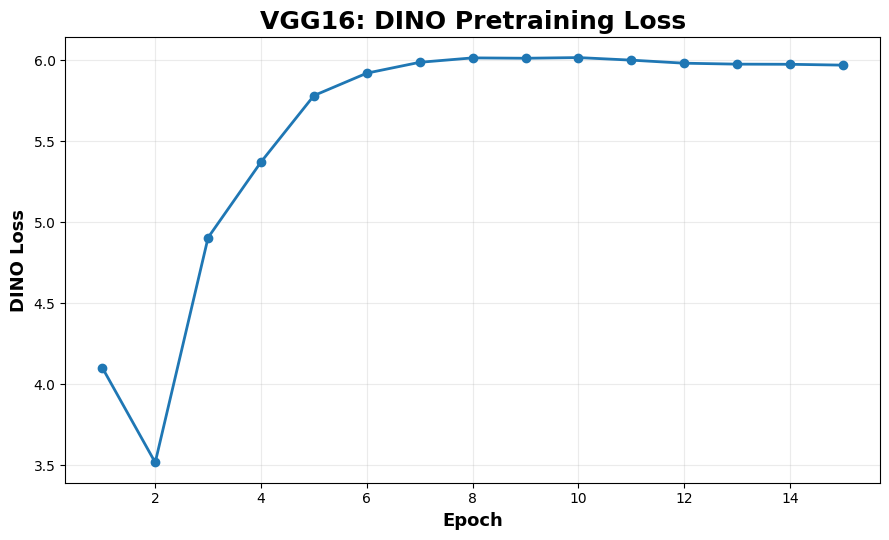


ResNet50: DINO self-supervised pretraining (unlabeled)


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

ResNet50 DINO pretrain epoch 1/15:   0%|          | 0/570 [00:00<?, ?it/s]

ResNet50 | DINO pretrain | epoch 01/15 | loss 5.2705 | skipped batches so far: 0


ResNet50 DINO pretrain epoch 2/15:   0%|          | 0/570 [00:00<?, ?it/s]

...

ResNet50 | DINO pretrain | epoch 13/15 | loss 7.5299 | skipped batches so far: 0


ResNet50 DINO pretrain epoch 14/15:   0%|          | 0/570 [00:00<?, ?it/s]

ResNet50 | DINO pretrain | epoch 14/15 | loss 7.5274 | skipped batches so far: 0


ResNet50 DINO pretrain epoch 15/15:   0%|          | 0/570 [00:00<?, ?it/s]

ResNet50 | DINO pretrain | epoch 15/15 | loss 7.5275 | skipped batches so far: 0
ResNet50: DINO pretraining finished in 89.5 min.


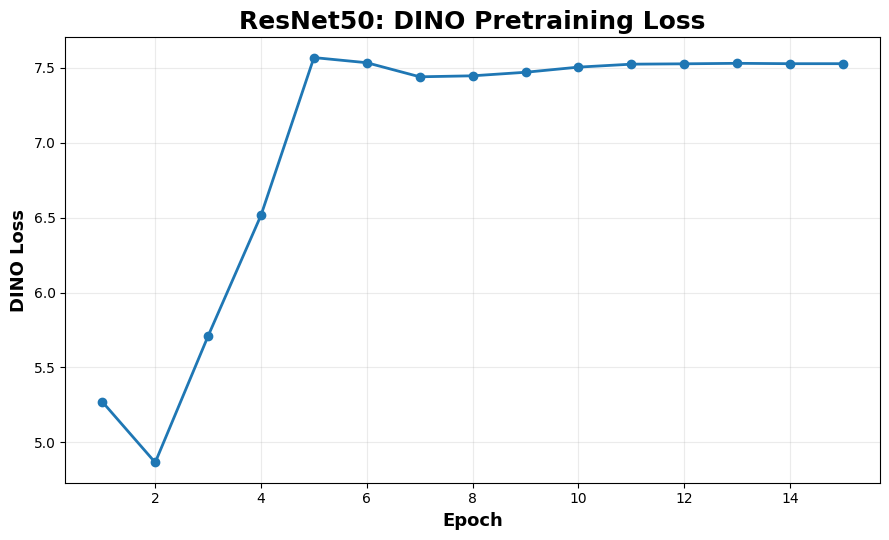


ConvNeXtSmall: DINO self-supervised pretraining (unlabeled)


model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

ConvNeXtSmall DINO pretrain epoch 1/15:   0%|          | 0/570 [00:00<?, ?it/s]

ConvNeXtSmall | DINO pretrain | epoch 01/15 | loss 4.1847 | skipped batches so far: 0


ConvNeXtSmall DINO pretrain epoch 2/15:   0%|          | 0/570 [00:00<?, ?it/s]

...

ConvNeXtSmall | DINO pretrain | epoch 13/15 | loss 4.7918 | skipped batches so far: 0


ConvNeXtSmall DINO pretrain epoch 14/15:   0%|          | 0/570 [00:00<?, ?it/s]

ConvNeXtSmall | DINO pretrain | epoch 14/15 | loss 4.7913 | skipped batches so far: 0


ConvNeXtSmall DINO pretrain epoch 15/15:   0%|          | 0/570 [00:00<?, ?it/s]

ConvNeXtSmall | DINO pretrain | epoch 15/15 | loss 4.7843 | skipped batches so far: 0
ConvNeXtSmall: DINO pretraining finished in 96.1 min.


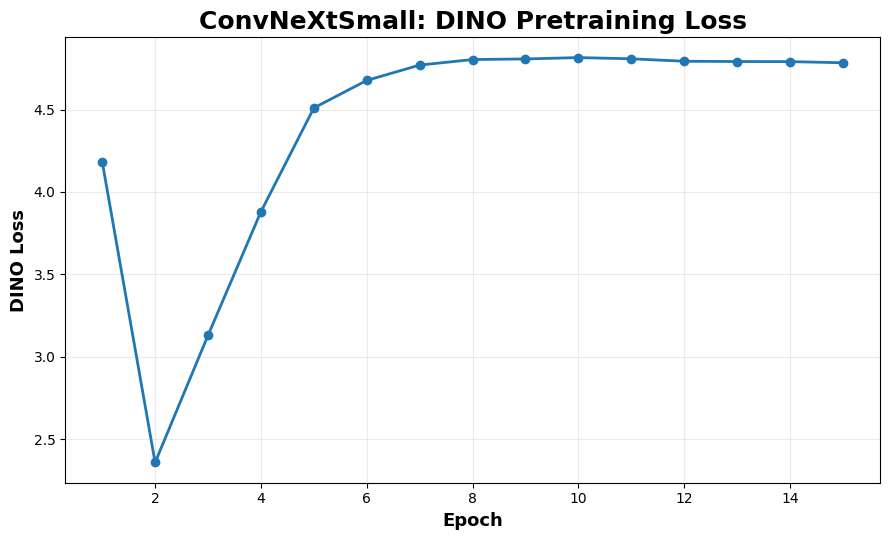

In [11]:
def pretrain_dino(model_label):
    backbone_ckpt = CHECKPOINT_DIR / f'{model_label.lower()}_dino_backbone.pth'
    state_ckpt = CHECKPOINT_DIR / f'{model_label.lower()}_dino_state.pth'
    history_path = TABLE_DIR / f'{model_label.lower()}_dino_pretrain_history.csv'

    if RESUME_IF_AVAILABLE and backbone_ckpt.exists():
        payload = load_checkpoint(backbone_ckpt, DEVICE)
        if payload.get('experiment_id') == EXPERIMENT_ID:
            print(f'{model_label}: DINO pretraining already completed, reusing saved backbone.')
            return backbone_ckpt

    student, teacher, timm_name, feature_dim, mean, std = build_dino(model_label)
    use_amp_for_model = USE_AMP and model_label not in AMP_UNSTABLE_MODELS

    def local_autocast(training=True):
        if use_amp_for_model and training:
            return torch.autocast(device_type='cuda', dtype=torch.float16)
        return nullcontext()
    student = student.to(DEVICE)
    teacher = teacher.to(DEVICE)
    teacher.eval()

    pretrain_dataset, pretrain_loader = make_dino_loader(mean, std)
    steps_per_epoch = len(pretrain_loader)
    total_steps = max(steps_per_epoch * DINO_PRETRAIN_EPOCHS, 1)
    warmup_steps = max(int(total_steps * DINO_WARMUP_STEPS_RATIO), 1)

    dino_loss_fn = DINOLoss(
        DINO_OUT_DIM, DINO_WARMUP_TEACHER_TEMP, DINO_TEACHER_TEMP,
        DINO_TEACHER_TEMP_WARMUP_EPOCHS, DINO_PRETRAIN_EPOCHS,
        student_temp=DINO_STUDENT_TEMP, center_momentum=DINO_CENTER_MOMENTUM,
    ).to(DEVICE)

    backbone_parameters = list(student.backbone.parameters())
    head_parameters = list(student.head.parameters())
    student_parameters = backbone_parameters + head_parameters

    optimizer = torch.optim.AdamW([
        {'params': backbone_parameters, 'lr': DINO_BACKBONE_LR},
        {'params': head_parameters, 'lr': DINO_HEAD_LR},
    ], weight_decay=DINO_WEIGHT_DECAY)

    base_lrs = [group['lr'] for group in optimizer.param_groups]

    def lr_at(step):
        if step < warmup_steps:
            return [lr * (step + 1) / warmup_steps for lr in base_lrs]
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        progress = min(max(progress, 0.0), 1.0)
        return [lr * 0.5 * (1 + math.cos(math.pi * progress)) for lr in base_lrs]

    try:
        scaler = torch.amp.GradScaler('cuda', enabled=use_amp_for_model)
    except Exception:
        scaler = torch.cuda.amp.GradScaler(enabled=use_amp_for_model)

    history = []
    start_epoch = 0
    global_step = 0
    skipped_batches = 0

    if RESUME_IF_AVAILABLE and state_ckpt.exists():
        state = load_checkpoint(state_ckpt, DEVICE)
        if state.get('experiment_id') == EXPERIMENT_ID and state.get('model_label') == model_label:
            student.load_state_dict(state['student_state_dict'])
            teacher.load_state_dict(state['teacher_state_dict'])
            dino_loss_fn.load_state_dict(state['dino_loss_state_dict'])
            optimizer.load_state_dict(state['optimizer_state_dict'])
            start_epoch = state['epoch']
            global_step = state['global_step']
            history = state['history']
            print(f'{model_label}: resuming DINO pretraining from epoch {start_epoch}.')

    if start_epoch < DINO_PRETRAIN_EPOCHS:
        training_start = time.perf_counter()

        for epoch in range(start_epoch, DINO_PRETRAIN_EPOCHS):
            student.train()
            running_loss = 0.0
            seen = 0
            progress = tqdm(
                pretrain_loader, leave=False,
                desc=f'{model_label} DINO pretrain epoch {epoch + 1}/{DINO_PRETRAIN_EPOCHS}',
            )

            for crops in progress:
                crops = [crop.to(DEVICE, non_blocking=True) for crop in crops]
                global_crops = crops[:DINO_GLOBAL_CROPS]

                momentum = momentum_schedule(global_step, total_steps)
                for group, lr in zip(optimizer.param_groups, lr_at(global_step)):
                    group['lr'] = lr

                optimizer.zero_grad(set_to_none=True)

                with local_autocast(True):
                    student_output = student(crops)
                    student_outputs = list(student_output.split(crops[0].size(0), dim=0))

                    with torch.no_grad():
                        teacher_output = teacher(global_crops)
                        teacher_outputs = list(teacher_output.split(global_crops[0].size(0), dim=0))

                    loss = dino_loss_fn(student_outputs, teacher_outputs, epoch)

                if not torch.isfinite(loss):
                    skipped_batches += 1
                    print(f'{model_label}: non-finite loss at step {global_step}, skipping this batch '
                          f'({skipped_batches} skipped so far).')
                    optimizer.zero_grad(set_to_none=True)
                    global_step += 1
                    continue

                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(student_parameters, max_norm=DINO_GRAD_CLIP_NORM)
                scaler.step(optimizer)
                scaler.update()

                update_teacher(student, teacher, momentum)

                running_loss += loss.item() * crops[0].size(0)
                seen += crops[0].size(0)
                global_step += 1
                progress.set_postfix(loss=f'{loss.item():.4f}', m=f'{momentum:.5f}')

            epoch_loss = running_loss / max(seen, 1)
            history.append({'epoch': epoch + 1, 'loss': epoch_loss})

            print(
                f'{model_label} | DINO pretrain | epoch {epoch + 1:02d}/{DINO_PRETRAIN_EPOCHS} | '
                f'loss {epoch_loss:.4f} | skipped batches so far: {skipped_batches}'
            )

            torch.save({
                'experiment_id': EXPERIMENT_ID,
                'model_label': model_label,
                'epoch': epoch + 1,
                'global_step': global_step,
                'student_state_dict': student.state_dict(),
                'teacher_state_dict': teacher.state_dict(),
                'dino_loss_state_dict': dino_loss_fn.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history,
            }, state_ckpt)

        training_seconds = time.perf_counter() - training_start
        print(f'{model_label}: DINO pretraining finished in {training_seconds / 60:.1f} min.')
    else:
        print(f'{model_label}: DINO pretraining already complete at epoch {start_epoch}.')

    # The teacher is the higher-quality representation in DINO (it is the running average
    # the student is distilled toward), so its backbone is what gets carried into fine-tuning.
    torch.save({
        'experiment_id': EXPERIMENT_ID,
        'model_label': model_label,
        'timm_name': timm_name,
        'backbone_state_dict': teacher.backbone.state_dict(),
        'feature_dim': feature_dim,
        'mean': mean,
        'std': std,
        'pretrained_init': PRETRAINED_INIT,
    }, backbone_ckpt)

    history_frame = pd.DataFrame(history)
    history_frame.to_csv(history_path, index=False)

    fig, axis = plt.subplots(figsize=(9, 5.5))
    axis.plot(history_frame['epoch'], history_frame['loss'], marker='o', linewidth=2)
    axis.set_title(f'{model_label}: DINO Pretraining Loss', fontsize=18, fontweight='bold')
    axis.set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axis.set_ylabel('DINO Loss', fontsize=13, fontweight='bold')
    axis.grid(alpha=0.25)
    fig.tight_layout()
    save_figure(fig, f'dino_pretrain_loss_{model_label.lower()}')
    plt.show()

    student.to('cpu')
    teacher.to('cpu')
    del student, teacher, dino_loss_fn, optimizer
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    return backbone_ckpt


for model_label in MODELS_TO_RUN:
    print('\n' + '=' * 88)
    print(f'{model_label}: DINO self-supervised pretraining (unlabeled)')
    print('=' * 88)
    pretrain_dino(model_label)


## Supervised Fine-Tuning on the DINO Backbones

Identical two-stage protocol (linear-probe then full fine-tune) as the BYOL
notebook, loading the DINO-pretrained (teacher) backbone instead of a BYOL one.


In [12]:
class TransferClassifier(nn.Module):
    def __init__(self, timm_name, num_classes, pretrained=False):
        super().__init__()
        self.backbone = timm.create_model(timm_name, pretrained=pretrained, num_classes=0, global_pool='avg')
        feature_count = int(
            self.backbone.head_hidden_size
            if hasattr(self.backbone, 'head_hidden_size')
            else self.backbone.num_features
        )
        self.classifier = nn.Sequential(
            nn.Dropout(DROPOUT),
            nn.Linear(feature_count, num_classes),
        )

    def forward(self, inputs):
        features = self.backbone(inputs)
        return self.classifier(features)


def build_finetune_model(model_label):
    backbone_ckpt = CHECKPOINT_DIR / f'{model_label.lower()}_dino_backbone.pth'
    if not backbone_ckpt.exists():
        raise FileNotFoundError(f'No DINO backbone checkpoint found for {model_label}. Run pretraining first.')

    payload = load_checkpoint(backbone_ckpt, DEVICE)
    timm_name = payload['timm_name']

    model = TransferClassifier(timm_name, len(class_names), pretrained=False)
    model.backbone.load_state_dict(payload['backbone_state_dict'], strict=True)

    mean = payload['mean']
    std = payload['std']
    return model, timm_name, mean, std


def freeze_batchnorm(model):
    for module in model.backbone.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            module.eval()
            for parameter in module.parameters():
                parameter.requires_grad = False


def configure_stage(model, stage):
    if stage == 'head':
        for parameter in model.backbone.parameters():
            parameter.requires_grad = False
        for parameter in model.classifier.parameters():
            parameter.requires_grad = True
    else:
        for parameter in model.parameters():
            parameter.requires_grad = True


def make_optimizer(model, stage):
    if stage == 'head':
        return torch.optim.AdamW(model.classifier.parameters(), lr=HEAD_LR, weight_decay=WEIGHT_DECAY)

    return torch.optim.AdamW([
        {'params': model.backbone.parameters(), 'lr': BACKBONE_LR},
        {'params': model.classifier.parameters(), 'lr': FINE_TUNE_HEAD_LR},
    ], weight_decay=WEIGHT_DECAY)


def run_epoch(model, loader, criterion, optimizer=None, scaler=None, stage='fine_tune'):
    training = optimizer is not None
    model.train(training)

    if training and stage == 'head':
        model.backbone.eval()
    if training and stage == 'fine_tune':
        freeze_batchnorm(model)

    running_loss = 0.0
    labels_all = []
    predictions_all = []

    progress = tqdm(loader, leave=False, desc='Training' if training else 'Validation')

    for images, labels, _ in progress:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with autocast_context(training):
                logits = model(images)
                loss = criterion(logits, labels)

            if not torch.isfinite(logits).all():
                raise RuntimeError(f'Non-finite logits during {"training" if training else "validation"}.')
            if not torch.isfinite(loss):
                raise RuntimeError(f'Non-finite loss during {"training" if training else "validation"}.')

            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                scaler.step(optimizer)
                scaler.update()

        running_loss += loss.item() * labels.size(0)
        labels_all.extend(labels.detach().cpu().numpy())
        predictions_all.extend(logits.argmax(dim=1).detach().cpu().numpy())
        progress.set_postfix(loss=f'{loss.item():.4f}')

    epoch_loss = running_loss / len(loader.dataset)
    epoch_accuracy = accuracy_score(labels_all, predictions_all)
    epoch_f1 = f1_score(labels_all, predictions_all, average='macro', zero_division=0)

    return epoch_loss, epoch_accuracy, epoch_f1


def save_history_plot(history, model_label):
    frame = pd.DataFrame(history)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

    axes[0].plot(frame['epoch'], frame['train_loss'], marker='o', linewidth=2, label='Train Loss')
    axes[0].plot(frame['epoch'], frame['val_loss'], marker='o', linewidth=2, label='Validation Loss')
    axes[0].set_title('Training and Validation Loss', fontsize=18, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Loss', fontsize=13, fontweight='bold')
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=11)

    axes[1].plot(frame['epoch'], frame['train_accuracy'], marker='o', linewidth=2, label='Train Accuracy')
    axes[1].plot(frame['epoch'], frame['val_accuracy'], marker='o', linewidth=2, label='Validation Accuracy')
    axes[1].set_title('Training and Validation Accuracy', fontsize=18, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Accuracy', fontsize=13, fontweight='bold')
    axes[1].set_ylim(0, 1.02)
    axes[1].grid(alpha=0.25)
    axes[1].legend(fontsize=11)

    fine_tune_epochs = frame.loc[frame['stage'] == 'fine_tune', 'epoch']
    if len(fine_tune_epochs):
        fine_tune_start = fine_tune_epochs.min()
        for axis in axes:
            axis.axvline(fine_tune_start - 0.5, linestyle='--', linewidth=1.5, label='Fine-tuning starts')

    fig.suptitle(f'{model_label}: DINO Fine-Tuning History', fontsize=22, fontweight='bold', y=1.02)
    fig.tight_layout()
    save_figure(fig, f'finetune_history_{model_label.lower()}')
    plt.show()


def train_finetune_model(model_label):
    checkpoint_path = CHECKPOINT_DIR / f'{model_label.lower()}_dino_finetuned_best.pth'
    history_path = TABLE_DIR / f'{model_label.lower()}_dino_finetune_history.csv'
    metadata_path = TABLE_DIR / f'{model_label.lower()}_dino_finetune_training.json'

    model, timm_name, mean, std = build_finetune_model(model_label)
    model = model.to(DEVICE)

    train_loader, val_loader, test_loader = make_loaders(mean, std)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
    scaler = make_scaler()

    history = []
    best_score = -np.inf
    best_val_loss = np.inf
    best_epoch = 0
    global_epoch = 0
    training_start = time.perf_counter()

    stages = [('head', HEAD_EPOCHS), ('fine_tune', FINE_TUNE_EPOCHS)]

    for stage, stage_epochs in stages:
        if stage == 'fine_tune' and checkpoint_path.exists():
            checkpoint = load_checkpoint(checkpoint_path, DEVICE)
            model.load_state_dict(checkpoint['model_state_dict'])

        configure_stage(model, stage)
        optimizer = make_optimizer(model, stage)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=2, min_lr=1e-7,
        )
        patience_count = 0

        for _ in range(stage_epochs):
            global_epoch += 1

            train_loss, train_accuracy, train_f1 = run_epoch(
                model, train_loader, criterion, optimizer, scaler, stage,
            )
            val_loss, val_accuracy, val_f1 = run_epoch(model, val_loader, criterion)

            scheduler.step(val_f1)
            learning_rates = [group['lr'] for group in optimizer.param_groups]

            history.append({
                'epoch': global_epoch, 'stage': stage,
                'train_loss': train_loss, 'val_loss': val_loss,
                'train_accuracy': train_accuracy, 'val_accuracy': val_accuracy,
                'train_f1': train_f1, 'val_f1': val_f1,
                'learning_rate': max(learning_rates),
            })

            improved = (
                val_f1 > best_score + MIN_DELTA
                or (abs(val_f1 - best_score) <= MIN_DELTA and val_loss < best_val_loss)
            )

            if improved:
                best_score = val_f1
                best_val_loss = val_loss
                best_epoch = global_epoch
                patience_count = 0

                torch.save({
                    'experiment_id': EXPERIMENT_ID,
                    'model_state_dict': model.state_dict(),
                    'model_label': model_label,
                    'timm_name': timm_name,
                    'class_names': class_names,
                    'mean': mean,
                    'std': std,
                    'input_size': INPUT_SIZE,
                    'batch_size': BATCH_SIZE,
                    'best_epoch': best_epoch,
                    'best_val_f1': float(best_score),
                    'best_val_loss': float(best_val_loss),
                }, checkpoint_path)
            else:
                patience_count += 1

            print(
                f'{model_label} | {stage} | epoch {global_epoch:02d} | '
                f'train loss {train_loss:.4f} | val loss {val_loss:.4f} | '
                f'train acc {train_accuracy:.4f} | val acc {val_accuracy:.4f}'
            )

            if stage == 'fine_tune' and patience_count >= PATIENCE:
                print(f'Early stopping at epoch {global_epoch}.')
                break

    training_seconds = time.perf_counter() - training_start
    best_checkpoint = load_checkpoint(checkpoint_path, DEVICE)
    model.load_state_dict(best_checkpoint['model_state_dict'])

    history_frame = pd.DataFrame(history)
    history_frame.to_csv(history_path, index=False)

    metadata = {
        'experiment_id': EXPERIMENT_ID,
        'model': model_label,
        'timm_name': timm_name,
        'input_size': INPUT_SIZE,
        'batch_size': BATCH_SIZE,
        'head_epochs': HEAD_EPOCHS,
        'fine_tune_epochs': FINE_TUNE_EPOCHS,
        'best_epoch': best_epoch,
        'best_val_f1': float(best_score),
        'best_val_loss': float(best_val_loss),
        'training_seconds': float(training_seconds),
    }

    metadata_path.write_text(json.dumps(metadata, indent=2))
    save_history_plot(history, model_label)

    return model, val_loader, test_loader, metadata


## Evaluation Utilities

In [13]:
def predict_classes(model, loader):
    model.eval()
    labels_all = []
    predictions_all = []
    paths_all = []
    start = time.perf_counter()

    with torch.no_grad():
        for images, labels, paths in tqdm(loader, leave=False, desc='Predicting'):
            images = images.to(DEVICE, non_blocking=True)

            with autocast_context(False):
                logits = model(images)

            predictions = logits.argmax(dim=1).cpu().numpy()
            labels_all.append(labels.numpy())
            predictions_all.append(predictions)
            paths_all.extend(paths)

    elapsed = time.perf_counter() - start

    return (
        np.concatenate(labels_all),
        np.concatenate(predictions_all),
        np.asarray(paths_all),
        elapsed,
    )


def calculate_metrics(y_true, y_pred):
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        'f1_score': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
    }


def plot_confusion_matrix(matrix, model_label):
    fig, axis = plt.subplots(figsize=(8.8, 7.5))
    image = axis.imshow(matrix, interpolation='nearest', cmap='Blues')
    colorbar = fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    colorbar.ax.tick_params(labelsize=12)

    threshold = matrix.max() / 2 if matrix.size else 0

    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value = int(matrix[row, column])
            axis.text(
                column, row, str(value),
                ha='center', va='center', fontsize=21, fontweight='bold',
                color='white' if value > threshold else 'black',
            )

    axis.set_xticks(np.arange(len(class_names)))
    axis.set_yticks(np.arange(len(class_names)))
    axis.set_xticklabels(class_names, rotation=18, ha='right', fontsize=14, fontweight='bold')
    axis.set_yticklabels(class_names, fontsize=14, fontweight='bold')
    axis.set_xlabel('Predicted Label', fontsize=17, fontweight='bold', labelpad=12)
    axis.set_ylabel('True Label', fontsize=17, fontweight='bold', labelpad=12)
    axis.set_title(f'DINO-{model_label} Confusion Matrix', fontsize=23, fontweight='bold', pad=16)

    fig.tight_layout()
    save_figure(fig, f'confusion_matrix_dino_{model_label.lower()}')
    plt.show()


def save_evaluation(model_label, model, test_loader, metadata):
    y_true, y_pred, paths, inference_seconds = predict_classes(model, test_loader)

    metrics = calculate_metrics(y_true, y_pred)
    metrics.update({
        'experiment_id': EXPERIMENT_ID,
        'model': f'DINO-{model_label}',
        'input_size': INPUT_SIZE,
        'batch_size': BATCH_SIZE,
        'best_epoch': metadata['best_epoch'],
        'training_seconds': metadata['training_seconds'],
        'inference_ms_per_image': float(inference_seconds * 1000 / len(y_true)),
    })

    report = classification_report(
        y_true, y_pred, labels=np.arange(len(class_names)),
        target_names=class_names, output_dict=True, zero_division=0,
    )
    pd.DataFrame(report).T.to_csv(TABLE_DIR / f'dino_{model_label.lower()}_classification_report.csv')

    pd.DataFrame({
        'path': paths,
        'true_label': [class_names[index] for index in y_true],
        'predicted_label': [class_names[index] for index in y_pred],
    }).to_csv(TABLE_DIR / f'dino_{model_label.lower()}_test_predictions.csv', index=False)

    (TABLE_DIR / f'dino_{model_label.lower()}_metrics.json').write_text(json.dumps(metrics, indent=2))

    matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    plot_confusion_matrix(matrix, model_label)

    return metrics


def completed_metrics(model_label):
    checkpoint_path = CHECKPOINT_DIR / f'{model_label.lower()}_dino_finetuned_best.pth'
    metrics_path = TABLE_DIR / f'dino_{model_label.lower()}_metrics.json'

    if not RESUME_IF_AVAILABLE:
        return None

    if checkpoint_path.exists() and metrics_path.exists():
        metrics = json.loads(metrics_path.read_text())
        if metrics.get('experiment_id') == EXPERIMENT_ID:
            return metrics

    return None


## Train and Evaluate DINO-VGG16, DINO-ResNet50, DINO-ConvNeXt Small


DINO-VGG16


Training:   0%|          | 0/286 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

VGG16 | head | epoch 01 | train loss 1.6572 | val loss 1.2274 | train acc 0.3504 | val acc 0.3544


Training:   0%|          | 0/286 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

VGG16 | fine_tune | epoch 29 | train loss 0.1843 | val loss 0.3754 | train acc 0.9997 | val acc 0.9110


Training:   0%|          | 0/286 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

VGG16 | fine_tune | epoch 30 | train loss 0.1835 | val loss 0.3693 | train acc 0.9998 | val acc 0.9171


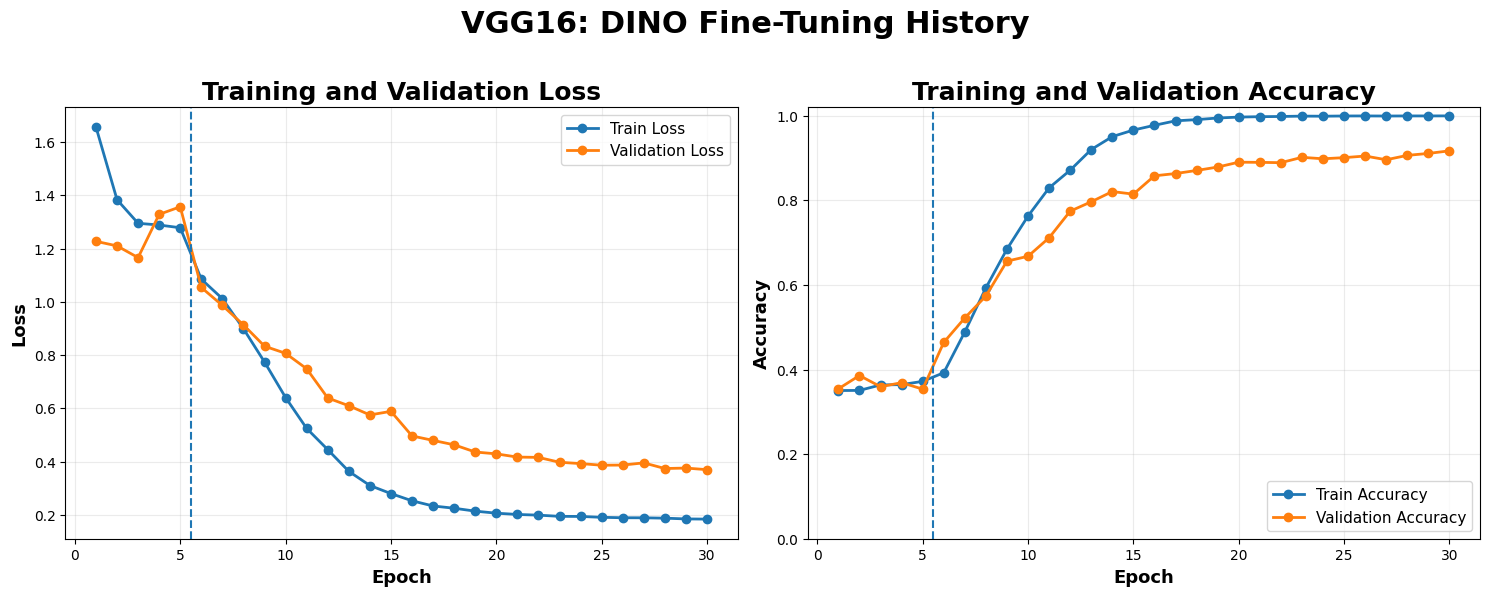

Predicting:   0%|          | 0/41 [00:00<?, ?it/s]

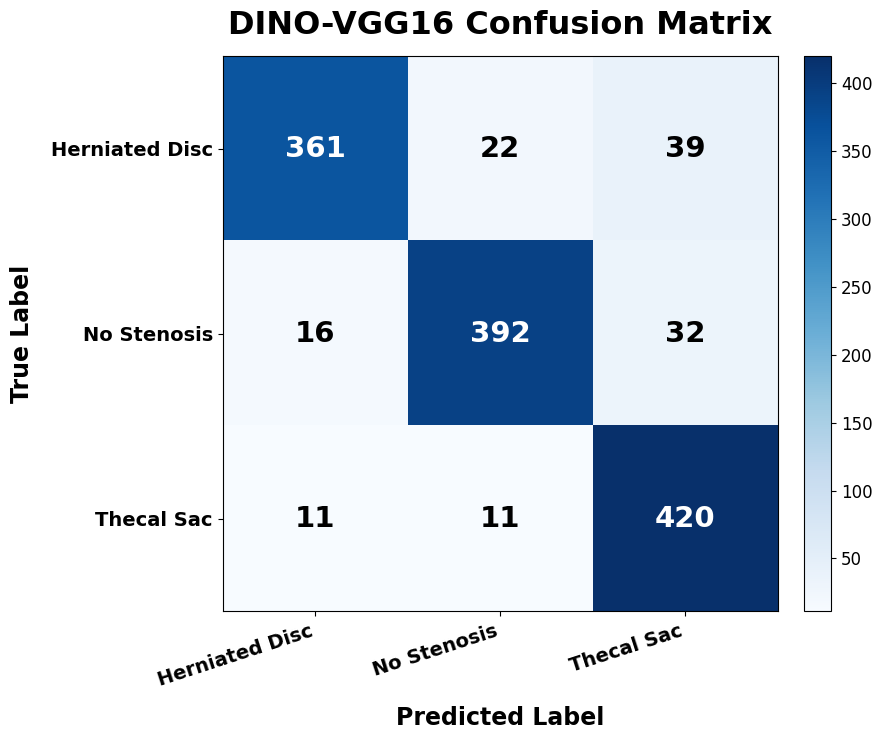

,Accuracy,Precision,Recall,F1 Score
Model,,,,
DINO-VGG16,0.89954,0.902721,0.898862,0.899346



DINO-ResNet50


Training:   0%|          | 0/286 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ResNet50 | head | epoch 01 | train loss 1.1455 | val loss 1.1029 | train acc 0.3338 | val acc 0.3510


...

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ResNet50 | fine_tune | epoch 29 | train loss 0.2685 | val loss 0.5380 | train acc 0.9665 | val acc 0.8239


Training:   0%|          | 0/286 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ResNet50 | fine_tune | epoch 30 | train loss 0.2644 | val loss 0.5374 | train acc 0.9701 | val acc 0.8354


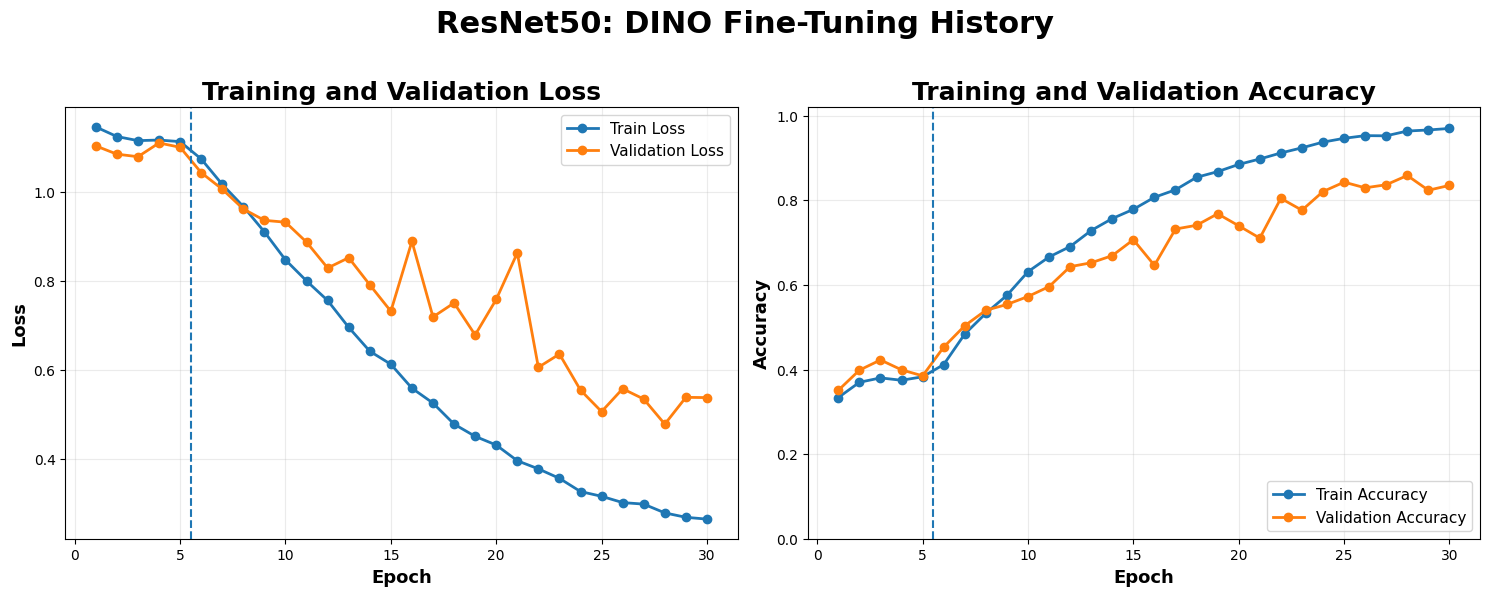

Predicting:   0%|          | 0/41 [00:00<?, ?it/s]

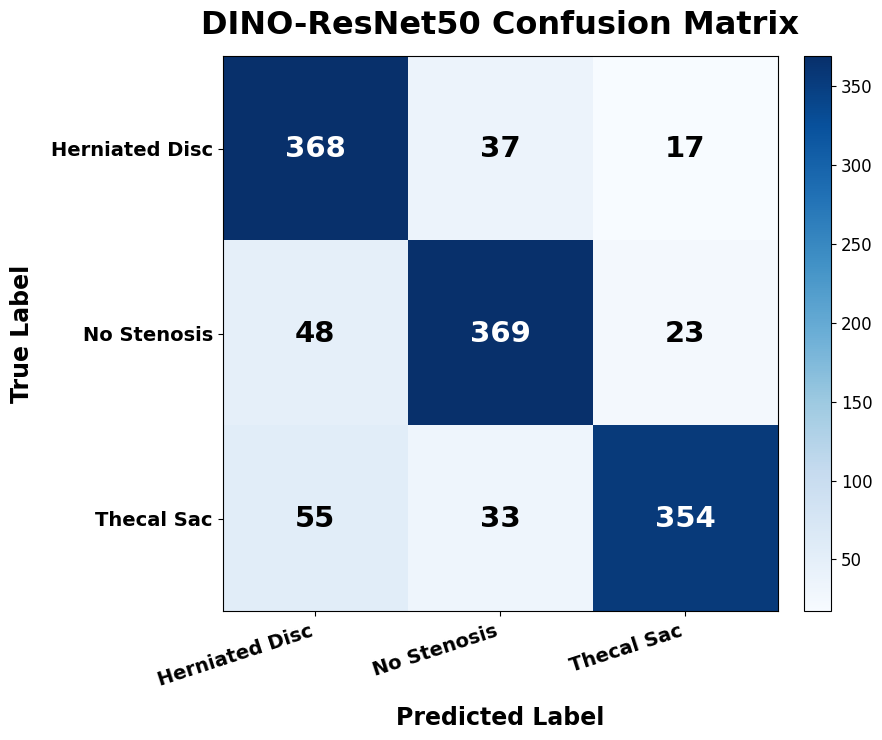

,Accuracy,Precision,Recall,F1 Score
Model,,,,
DINO-ResNet50,0.836656,0.840113,0.837193,0.83689



DINO-ConvNeXtSmall


Training:   0%|          | 0/286 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ConvNeXtSmall | head | epoch 01 | train loss 1.1439 | val loss 1.0753 | train acc 0.3699 | val acc 0.3959


...

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ConvNeXtSmall | fine_tune | epoch 29 | train loss 0.1849 | val loss 0.4173 | train acc 0.9992 | val acc 0.8830


Training:   0%|          | 0/286 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ConvNeXtSmall | fine_tune | epoch 30 | train loss 0.1829 | val loss 0.4293 | train acc 1.0000 | val acc 0.8796


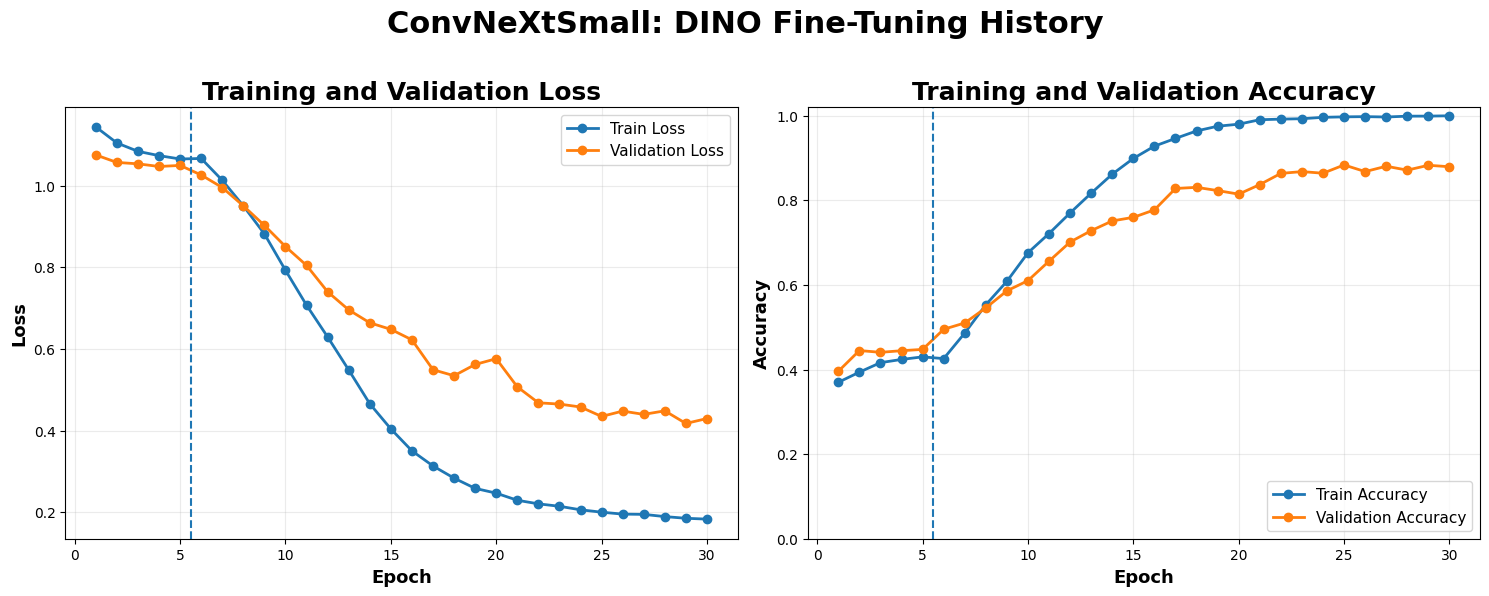

Predicting:   0%|          | 0/41 [00:00<?, ?it/s]

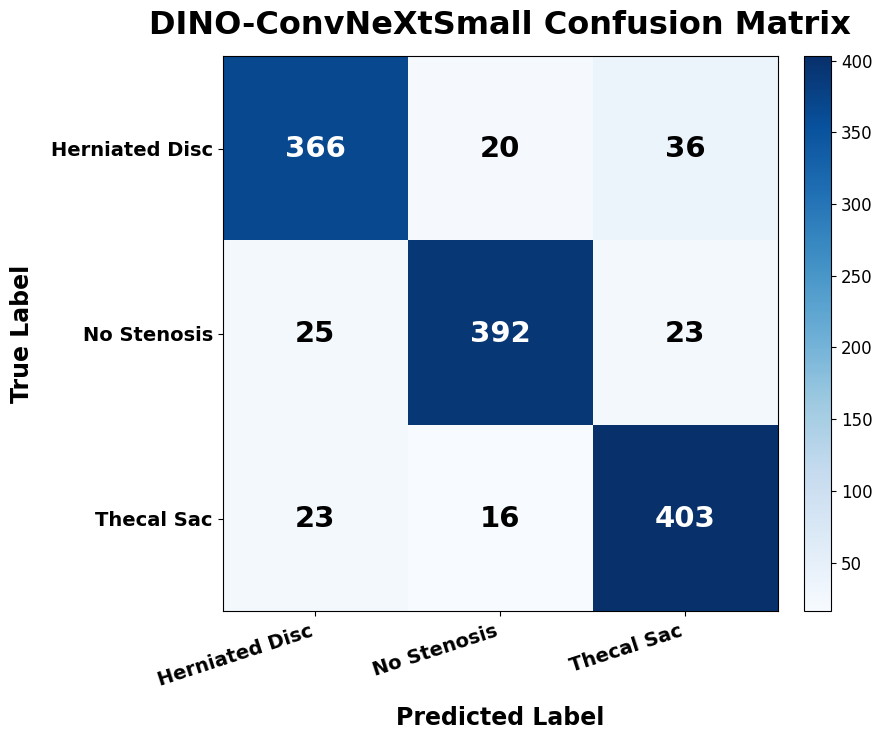

,Accuracy,Precision,Recall,F1 Score
Model,,,,
DINO-ConvNeXtSmall,0.890337,0.890747,0.889991,0.890139


In [14]:
all_metrics = []

for model_label in MODELS_TO_RUN:
    print('\n' + '=' * 88)
    print(f'DINO-{model_label}')
    print('=' * 88)

    saved = completed_metrics(model_label)

    if saved is not None:
        print('Loaded completed result for the current experiment configuration.')
        all_metrics.append(saved)
        continue

    model, val_loader, test_loader, metadata = train_finetune_model(model_label)
    metrics = save_evaluation(model_label, model, test_loader, metadata)

    all_metrics.append(metrics)

    display(pd.DataFrame([{
        'Model': f'DINO-{model_label}',
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1 Score': metrics['f1_score'],
    }]).set_index('Model'))

    model.to('cpu')
    del model, val_loader, test_loader
    gc.collect()

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


## Model Comparison

In [15]:
comparison = (
    pd.DataFrame(all_metrics)
    .sort_values('f1_score', ascending=False)
    .reset_index(drop=True)
)

comparison_table = comparison[['model', 'accuracy', 'precision', 'recall', 'f1_score']].copy()
comparison_table.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']

comparison_table.to_csv(TABLE_DIR / 'dino_model_comparison.csv', index=False)
(TABLE_DIR / 'dino_model_comparison.tex').write_text(
    comparison_table.to_latex(index=False, float_format='%.4f')
)

display(comparison_table)


,Model,Accuracy,Precision,Recall,F1 Score
0,DINO-VGG16,0.899540,0.902721,0.898862,0.899346
1,DINO-ConvNeXtSmall,0.890337,0.890747,0.889991,0.890139
2,DINO-ResNet50,0.836656,0.840113,0.837193,0.836890


## Export Paper Assets

In [16]:
run_summary = {
    'dataset': 'Lumbar Spinal MRI Dataset',
    'archive': str(ARCHIVE_PATH),
    'classes': class_names,
    'original_images': int(len(raw_df)),
    'retained_unique_images': int(len(cleaned_df)),
    'training_images': int(len(train_df)),
    'validation_images': int(len(val_df)),
    'test_images': int(len(test_df)),
    'split': {'train': TRAIN_RATIO, 'validation': VAL_RATIO, 'test': TEST_RATIO},
    'input_size': INPUT_SIZE,
    'method': METHOD_NAME,
    'pretrained_init': PRETRAINED_INIT,
    'dino_pretrain_epochs': DINO_PRETRAIN_EPOCHS,
    'dino_batch_size': DINO_BATCH_SIZE,
    'dino_global_crops': DINO_GLOBAL_CROPS,
    'dino_local_crops': DINO_LOCAL_CROPS,
    'dino_out_dim': DINO_OUT_DIM,
    'dino_base_momentum': DINO_BASE_MOMENTUM,
    'dino_teacher_temp': DINO_TEACHER_TEMP,
    'dino_student_temp': DINO_STUDENT_TEMP,
    'finetune_batch_size': BATCH_SIZE,
    'head_epochs': HEAD_EPOCHS,
    'fine_tune_epochs': FINE_TUNE_EPOCHS,
    'seed': SEED,
    'models': MODEL_SPECS,
    'preprocessing': [
        'foreground-aware crop',
        'robust 1st-99th percentile intensity normalization',
        'square padding',
        'three-channel conversion',
        '224x224 bicubic resizing',
        'DINO stage: multi-crop (2 global + N local) with asymmetric blur/solarize on global crops',
        'fine-tune stage: mild training-only affine and intensity augmentation',
        'pretrained-model normalization',
    ],
    'labeled_unlabeled_protocol': (
        'DINO pretraining uses only train-split images with labels discarded (identical protocol to '
        'the BYOL notebook). Validation/test are untouched until fine-tuning/evaluation respectively.'
    ),
    'patient_level_split_available': False,
}

(OUTPUT_DIR / 'run_summary.json').write_text(json.dumps(run_summary, indent=2))

readme = '\n'.join([
    'Lumbar Spinal MRI Classification — DINO Self-Supervised Study',
    '',
    f'Original images: {len(raw_df):,}',
    f'Unique retained images: {len(cleaned_df):,}',
    f'Training images: {len(train_df):,}',
    f'Validation images: {len(val_df):,}',
    f'Test images: {len(test_df):,}',
    f"Classes: {', '.join(class_names)}",
    f"Models: {', '.join('DINO-' + m for m in MODELS_TO_RUN)}",
    f'Input size: {INPUT_SIZE} x {INPUT_SIZE} (global crops), {DINO_LOCAL_CROP_SIZE} x {DINO_LOCAL_CROP_SIZE} (local crops)',
    f'DINO pretrain epochs: {DINO_PRETRAIN_EPOCHS}',
    f'DINO initialized from ImageNet weights: {PRETRAINED_INIT}',
    f'Global / local crops per image: {DINO_GLOBAL_CROPS} / {DINO_LOCAL_CROPS}',
    f'Head training epochs: {HEAD_EPOCHS}',
    f'Fine-tuning epochs: {FINE_TUNE_EPOCHS}',
    '',
    'The dataset does not expose patient identifiers. The requested split is image-level. '
    'Exact duplicate images are removed before splitting. DINO pretraining uses only the '
    'training-split images with labels discarded (self-supervised); labels are used only '
    'in the subsequent fine-tuning stage.',
])

(OUTPUT_DIR / 'README.txt').write_text(readme)

paper_zip = Path('/kaggle/working/lumbar_spinal_mri_dino_paper_assets.zip')

with zipfile.ZipFile(paper_zip, 'w', compression=zipfile.ZIP_DEFLATED) as archive:
    for folder in [FIGURE_DIR, TABLE_DIR]:
        for path in folder.rglob('*'):
            if path.is_file():
                archive.write(path, path.relative_to(OUTPUT_DIR))

    archive.write(OUTPUT_DIR / 'README.txt', 'README.txt')
    archive.write(OUTPUT_DIR / 'run_summary.json', 'run_summary.json')

print(f'Figures: {FIGURE_DIR}')
print(f'Tables: {TABLE_DIR}')
print(f'Checkpoints: {CHECKPOINT_DIR}')
print(f'Paper assets ZIP: {paper_zip}')


Figures: /kaggle/working/lumbar_mri_dino_224_v1/paper_figures
Tables: /kaggle/working/lumbar_mri_dino_224_v1/tables
Checkpoints: /kaggle/working/lumbar_mri_dino_224_v1/checkpoints
Paper assets ZIP: /kaggle/working/lumbar_spinal_mri_dino_paper_assets.zip
